In [1]:
import osmnx as ox
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from rasterstats import zonal_stats

Data Join: FCC Data to your Counties

In [2]:
# 1. Load the FCC data
fcc_data = pd.read_csv("../data/processed/fcc_wv_broadband.csv")

# 2. Extract County FIPS from the 15-digit Block ID
# We ensure it's a string and take the first 5 characters
fcc_data['county_fips'] = fcc_data['block_geoid'].astype(str).str.zfill(15).str[:5]

# 3. Define "High Speed" (e.g., Fiber/Cable)
# We consider a block 'served' if download speed >= 100 Mbps
fcc_data['is_served'] = fcc_data['max_advertised_download_speed'] >= 100

# 4. Aggregate by County
# We calculate the percentage of blocks in each county that have high-speed access
county_stats = fcc_data.groupby('county_fips')['is_served'].mean().reset_index()
county_stats.columns = ['county_fips', 'broadband_serve_pct']

wv_counties = gpd.read_file("../data/processed/wv_counties.gpkg").to_crs(epsg=4326)
# 5. Merge with your wv_counties GeoDataFrame
wv_counties = wv_counties.merge(county_stats, left_on="GEOID", right_on="county_fips", how="inner")

print(f"Merge successful! County count: {len(wv_counties)}")

Merge successful! County count: 55


Extract the County ID and Aggregate

In [5]:
# 1. FCC data is already loaded in the previous cell

# 2. Extract County FIPS from the 15-digit Block ID
# We ensure it's a string and take the first 5 characters
fcc_data['county_fips'] = fcc_data['block_geoid'].astype(str).str.zfill(15).str[:5]

# 3. Define "High Speed" (e.g., Fiber/Cable)
# We consider a block 'served' if download speed >= 100 Mbps
fcc_data['is_served'] = fcc_data['max_advertised_download_speed'] >= 100

# 4. Aggregate by County
# We calculate the percentage of blocks in each county that have high-speed access
county_stats = fcc_data.groupby('county_fips')['is_served'].mean().reset_index()
county_stats.columns = ['county_fips', 'broadband_serve_pct']

# 5. Merge with your wv_counties GeoDataFrame
wv_counties = wv_counties.merge(county_stats, left_on="GEOID", right_on="county_fips", how="inner")

print(f"Merge successful! County count: {len(wv_counties)}")

Merge successful! County count: 55


Clean duplicates

In [12]:
# 1. Clean the duplicates and keep only one version of the broadband column
if 'broadband_serve_pct_x' in wv_counties.columns:
    wv_counties['broadband_serve_pct'] = wv_counties['broadband_serve_pct_x']
    # Drop the messy _x and _y columns
    cols_to_drop = [c for c in wv_counties.columns if c.endswith('_x') or c.endswith('_y')]
    wv_counties = wv_counties.drop(columns=cols_to_drop)

# 2. Re-calculate the missing features
from rasterstats import zonal_stats

print("Calculating missing features...")
# Add Population
stats = zonal_stats(wv_counties, "../data/raw/usa_pop_1km.tif", stats="sum")
wv_counties['total_pop'] = [s['sum'] if s['sum'] is not None else 0 for s in stats]

# Add Road Density
roads = gpd.read_file("../data/processed/wv_roads.gpkg").to_crs(wv_counties.crs)
roads_in_county = gpd.sjoin(roads, wv_counties, predicate='within')
road_lengths = roads_in_county.groupby('NAME')['length'].sum()
wv_counties['road_density'] = wv_counties['NAME'].map(road_lengths).fillna(0)

# Add Distance to Backbone
backbone = roads[roads['highway'].isin(['motorway', 'trunk', 'primary'])]
wv_counties['dist_to_backbone_m'] = wv_counties.geometry.centroid.apply(
    lambda x: backbone.distance(x).min()
)

print("Check! Columns now include:", [c for c in wv_counties.columns if c in ['total_pop', 'road_density', 'dist_to_backbone_m', 'broadband_serve_pct']])

Calculating missing features...


/tmp/ipykernel_25552/2414684087.py:24: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  wv_counties['dist_to_backbone_m'] = wv_counties.geometry.centroid.apply(
/tmp/ipykernel_25552/2414684087.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lambda x: backbone.distance(x).min()


Check! Columns now include: ['broadband_serve_pct', 'total_pop', 'road_density', 'dist_to_backbone_m']


In [14]:
print(wv_counties.columns.tolist())

['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry', 'broadband_serve_pct', 'total_pop', 'road_density', 'dist_to_backbone_m']


EDA

Correlation Heatmap

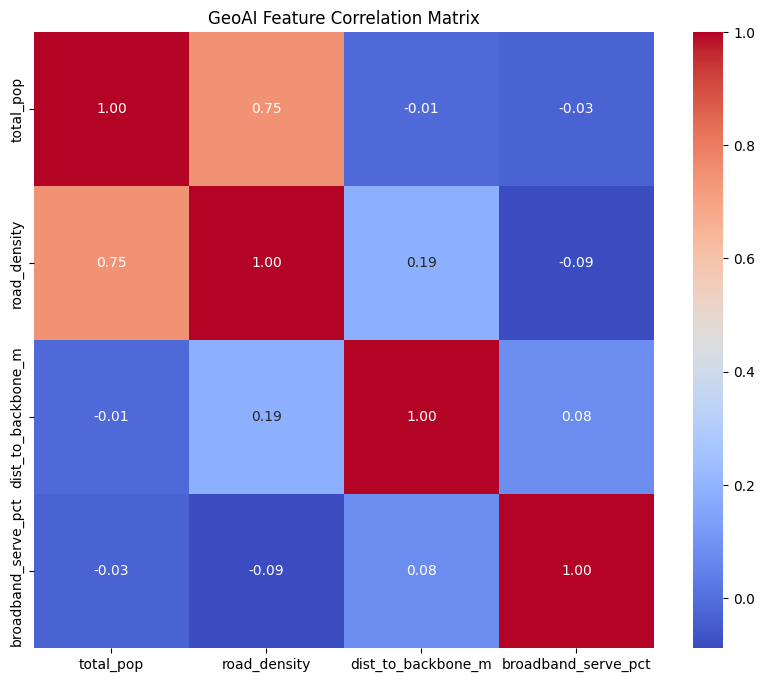

In [13]:
# Select the numerical columns we've created
features = ['total_pop', 'road_density', 'dist_to_backbone_m', 'broadband_serve_pct']
corr = wv_counties[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("GeoAI Feature Correlation Matrix")
plt.show()

Distribution Check (The "Gap" Visualizer)

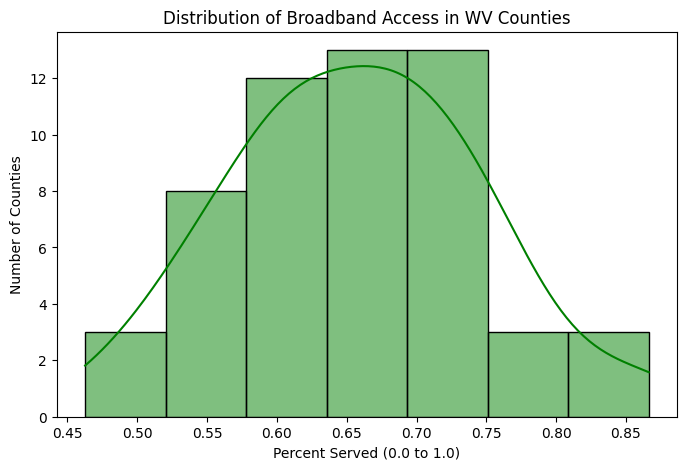

In [16]:
# Look at the distribution of Broadband Access across counties
plt.figure(figsize=(8, 5))
sns.histplot(wv_counties['broadband_serve_pct'], kde=True, color='green')
plt.title("Distribution of Broadband Access in WV Counties")
plt.xlabel("Percent Served (0.0 to 1.0)")
plt.ylabel("Number of Counties")
plt.show()

Many Counties do not have high-speed internet !!
Percent Served is a decimal representation of a percentage. 
It is our Target Variable (the thing we are trying to predict).

0.0 = 0% (No one in that county/block has high-speed internet).

1.0 = 100% (Every single household/block in that area has high-speed internet).

0.85 = 85% coverage.